In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data analysis python project - blinkit analysis

In [7]:
df=pd.read_csv("blinkit_data.csv")
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [8]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [10]:
print("size of data:",df.shape)

size of data: (8523, 12)


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item fat content           8523 non-null   str    
 1   item identifier            8523 non-null   str    
 2   item type                  8523 non-null   str    
 3   outlet establishment year  8523 non-null   int64  
 4   outlet identifier          8523 non-null   str    
 5   outlet location type       8523 non-null   str    
 6   outlet size                8523 non-null   str    
 7   outlet type                8523 non-null   str    
 8   item visibility            8523 non-null   float64
 9   item weight                7060 non-null   float64
 10  sales                      8523 non-null   float64
 11  rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [38]:
df.describe()

,outlet establishment year,item visibility,item weight,sales,rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [11]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [12]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

## data cleaning

In [39]:
df.columns=df.columns.str.lower()
df.columns

Index(['item fat content', 'item identifier', 'item type',
       'outlet establishment year', 'outlet identifier',
       'outlet location type', 'outlet size', 'outlet type', 'item visibility',
       'item weight', 'sales', 'rating'],
      dtype='str')

In [32]:
df["item fat content"].unique()

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [36]:
df["item fat content"]=df["item fat content"].replace({"LF":"low fat","Low Fat":"low fat","reg":"regular" ,"Regular":"regular"})
df["item fat content"].unique()

<StringArray>
['regular', 'low fat']
Length: 2, dtype: str

### business requirements

In [45]:
total_sales=df["sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $1,201,681.48


In [47]:
total_average=df["sales"].mean()
print(f"total average:${total_average:,.2f}")

total average:$140.99


In [50]:
no_of_item_sold=df["sales"].count()
print(f"no of item: {no_of_item_sold:,.0f}")

no of item: 8,523


In [51]:
avg_ratings=df["rating"].mean()
print(f"avg ratings:{avg_ratings:,.0f}")

avg ratings:4


### charts requirements

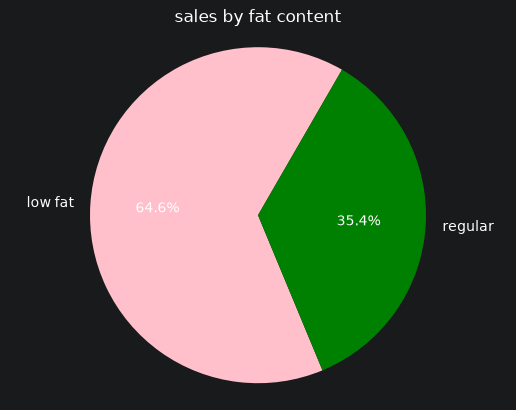

In [61]:
sales_fat=df.groupby("item fat content")["sales"].sum()
plt.pie(sales_fat, labels = sales_fat.index,
        autopct='%.1f%%',
        startangle=60,
        colors=["pink","green"])
plt.title("sales by fat content")
plt.axis("equal")
plt.show()

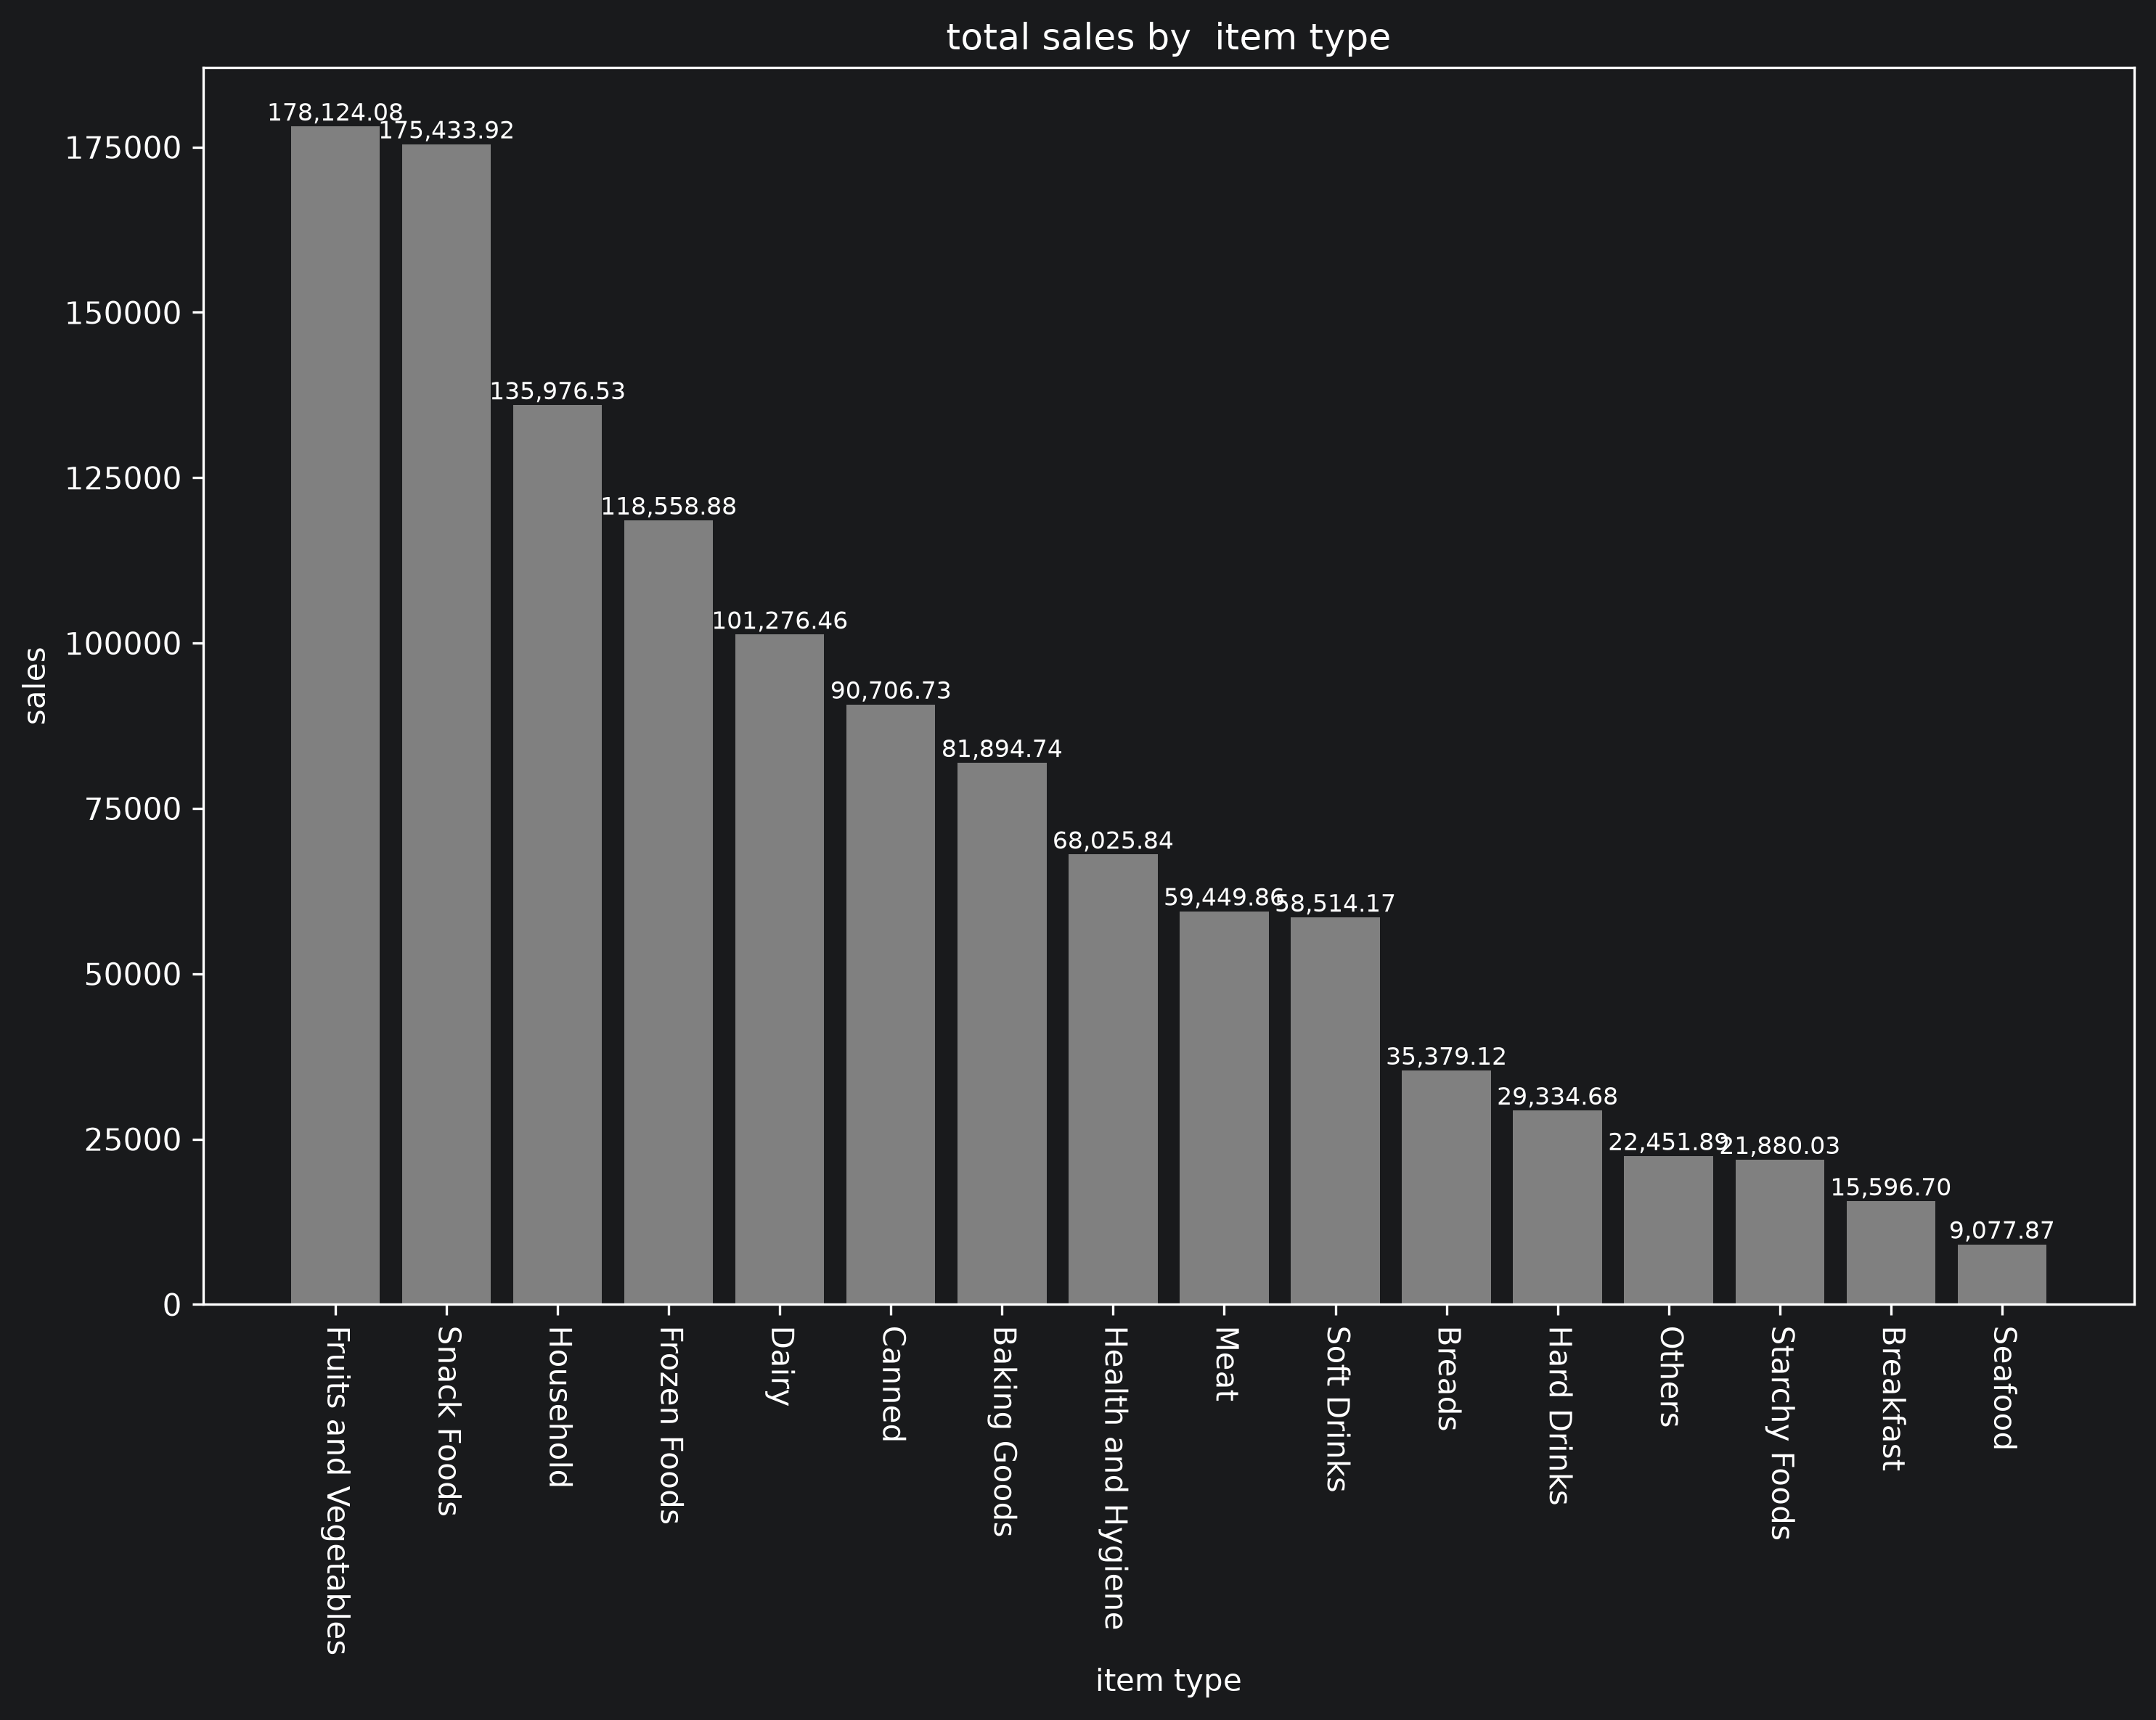

In [79]:
sales_type=df.groupby("item type")["sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,8),dpi=300)
bars=plt.bar(sales_type.index,sales_type.values,color="grey")
plt.xticks(rotation=-90)
plt.title("total sales by  item type")
plt.xlabel("item type")
plt.ylabel("sales")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),
             f'{bar.get_height():,.2f}',ha='center',va='bottom',fontsize=8)
plt.tight_layout()
plt.show()

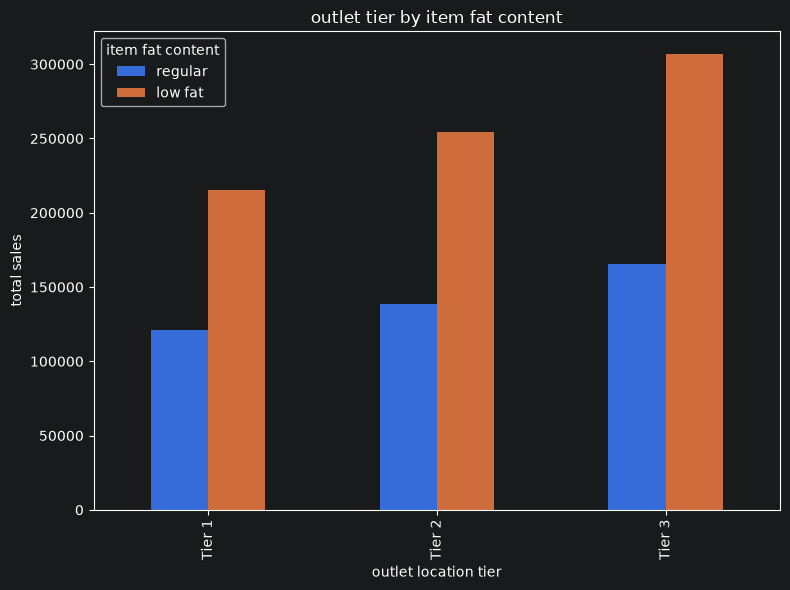

In [99]:
grouped=df.groupby(["outlet location type","item fat content"])["sales"].sum().unstack()
grouped=grouped[["regular","low fat"]]
ax=grouped.plot(kind="bar",figsize=(8,6),title="outlet tier by item fat content")
plt.xlabel("outlet location tier")
plt.ylabel("total sales")
plt.legend(title="item fat content")
plt.tight_layout()
plt.show()

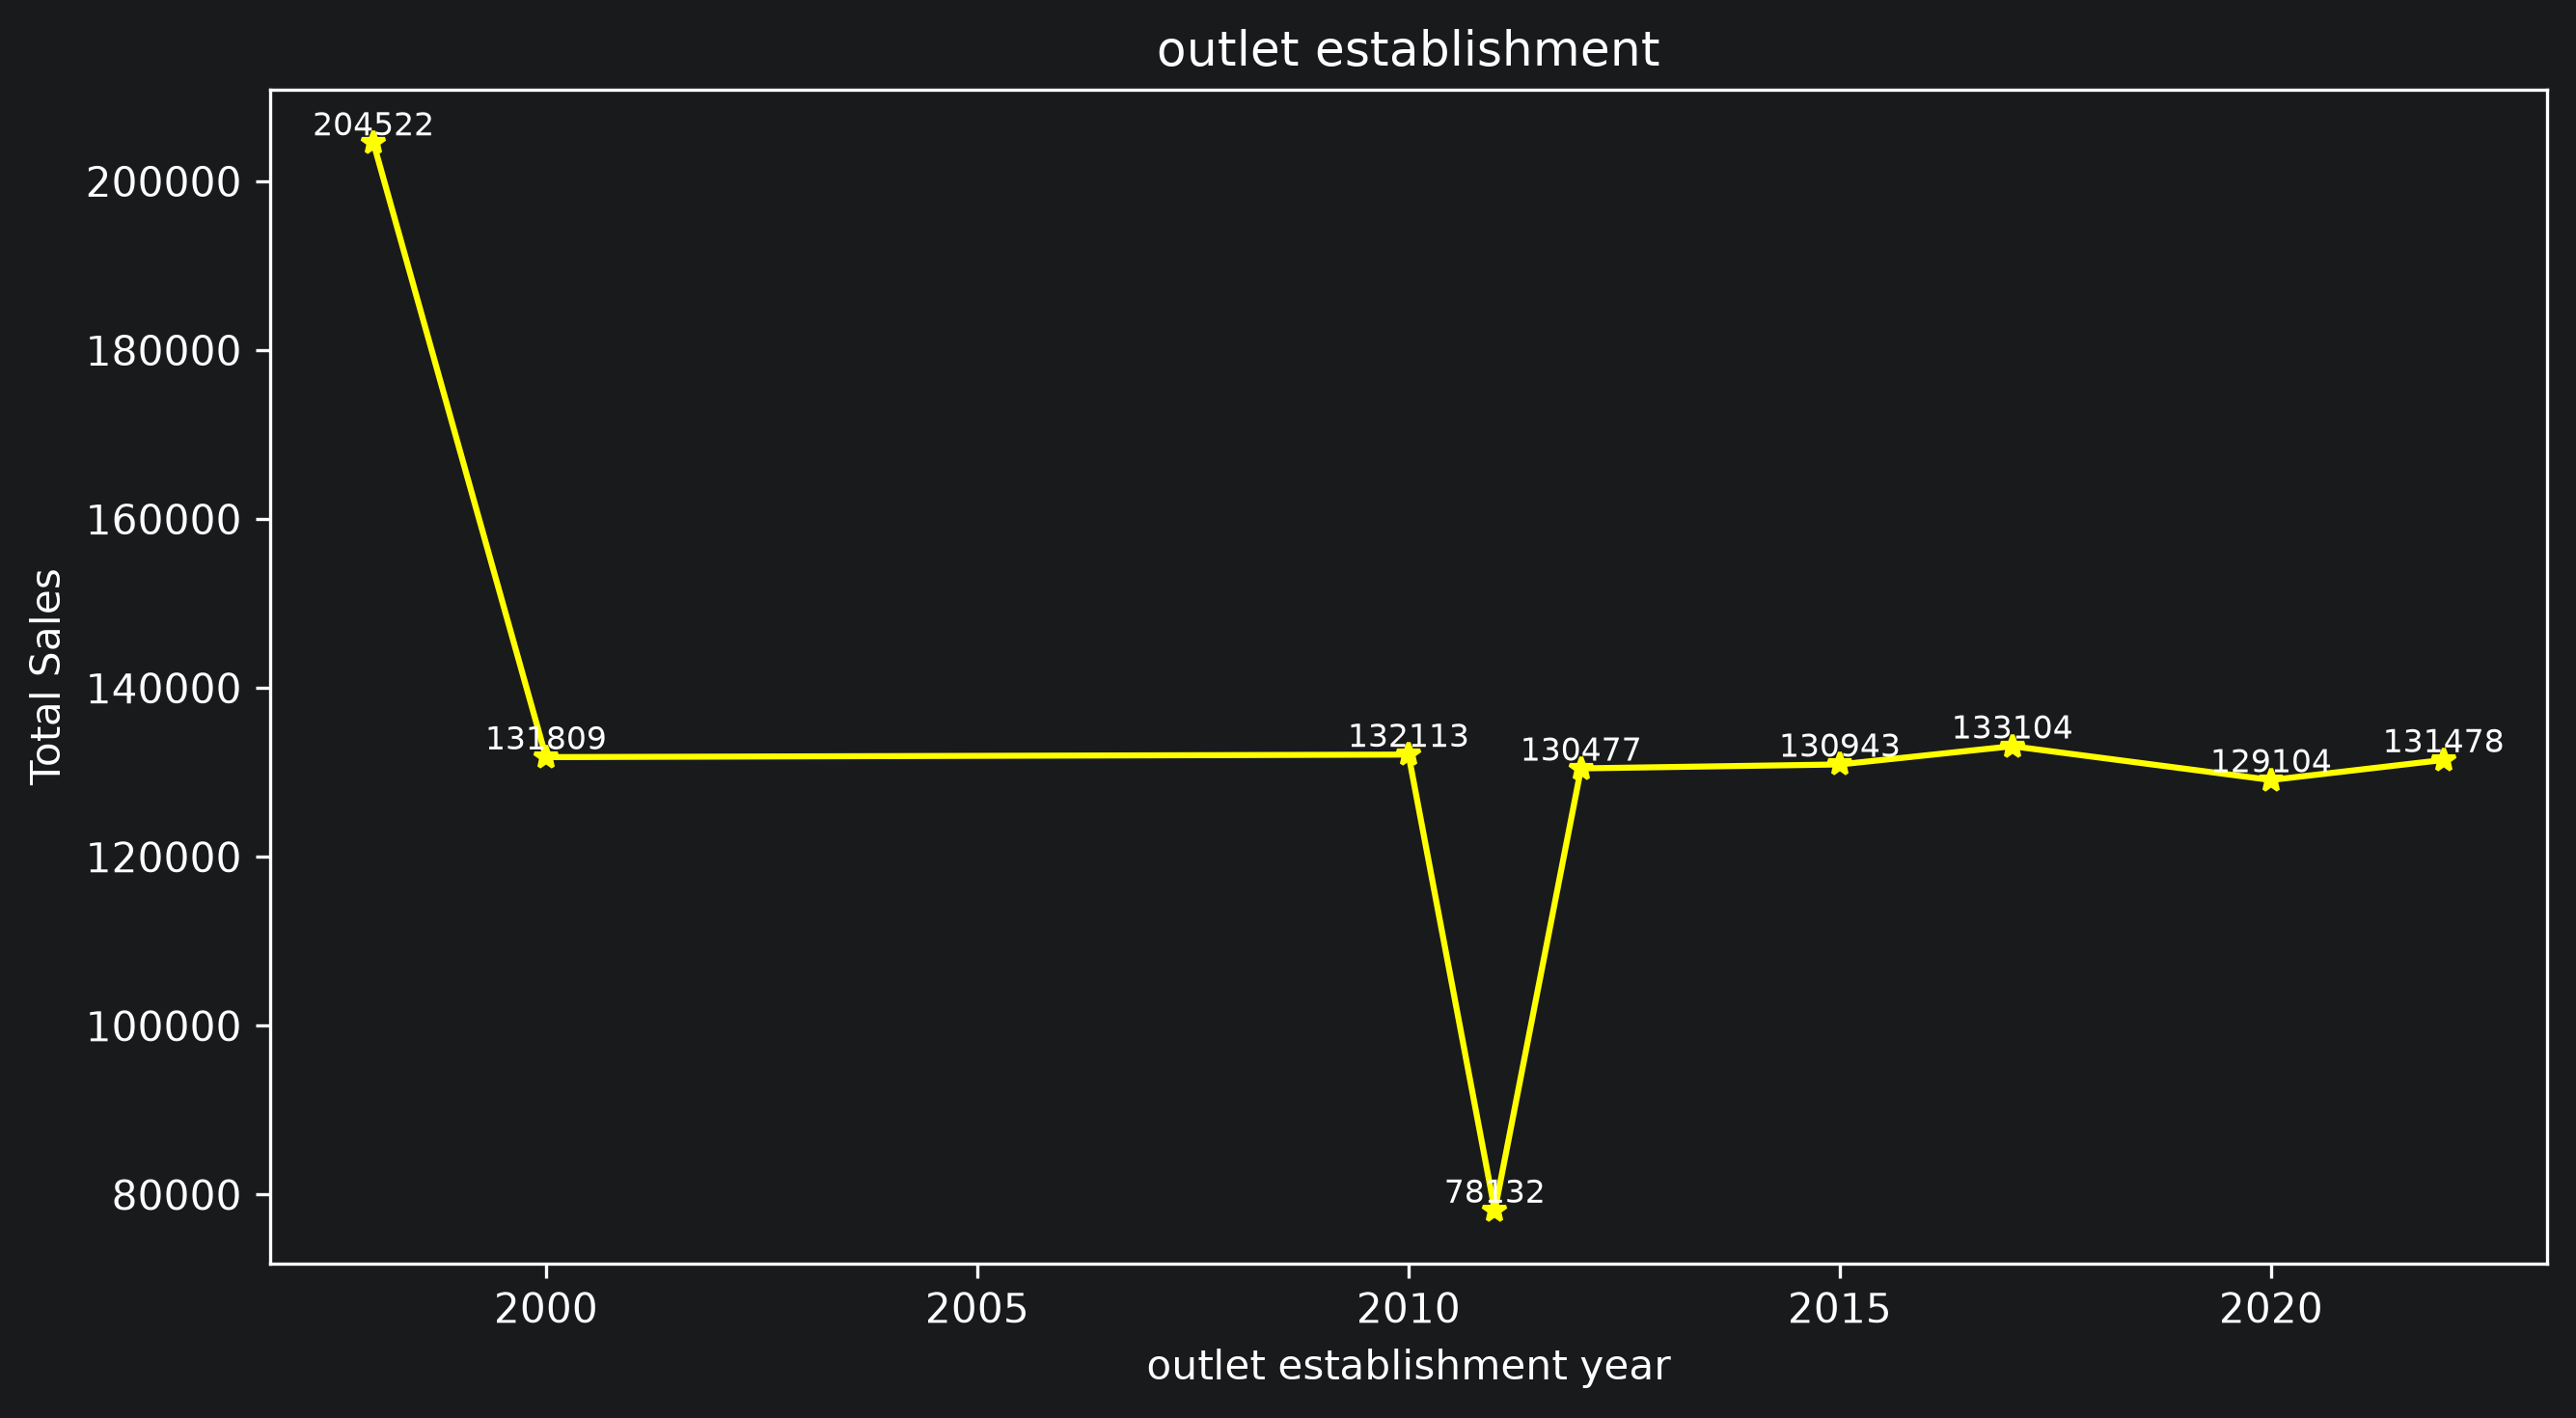

In [100]:
sales_by_year = df.groupby('outlet establishment year')['sales'].sum().sort_index()

plt.figure(figsize=(9,5),dpi=300)
plt.plot(sales_by_year.index, sales_by_year.values, marker='*', linestyle='-', color='yellow')
plt.xlabel("outlet establishment year")

plt.xlabel('outlet establishment year')
plt.ylabel('Total Sales')
plt.title('outlet establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

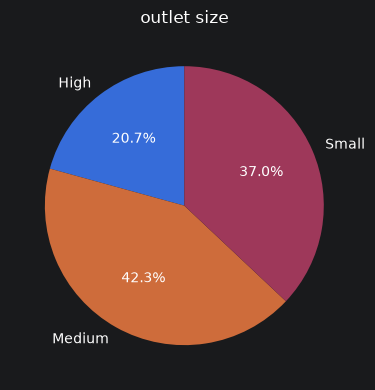

In [111]:
sales_size=df.groupby("outlet size")["sales"].sum()
plt.figure(figsize=(4,4))
plt.pie(sales_size, labels = sales_size.index,autopct='%.1f%%',startangle=90)
plt.title("outlet size")
plt.tight_layout()
plt.show()

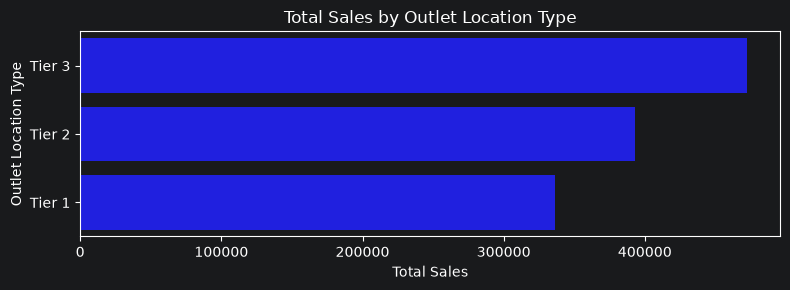

In [118]:
sales_by_location = df.groupby('outlet location type')['sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('sales', ascending=False)

plt.figure(figsize=(8, 3))

ax = sns.barplot(x='sales', y='outlet location type', data=sales_by_location,color='blue')
plt.xlabel("outlet location type")

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()